# Keras TF 2.0 - Code Along Classification Project

Let's explore a classification task with Keras API for TF 2.0

## The Data

### Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry 
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 3 is Mean Radius, field
        13 is Radius SE, field 23 is Worst Radius.

        - class:
                - WDBC-Malignant
                - WDBC-Benign

    :Summary Statistics:

    ===================================== ====== ======
                                           Min    Max
    ===================================== ====== ======
    radius (mean):                        6.981  28.11
    texture (mean):                       9.71   39.28
    perimeter (mean):                     43.79  188.5
    area (mean):                          143.5  2501.0
    smoothness (mean):                    0.053  0.163
    compactness (mean):                   0.019  0.345
    concavity (mean):                     0.0    0.427
    concave points (mean):                0.0    0.201
    symmetry (mean):                      0.106  0.304
    fractal dimension (mean):             0.05   0.097
    radius (standard error):              0.112  2.873
    texture (standard error):             0.36   4.885
    perimeter (standard error):           0.757  21.98
    area (standard error):                6.802  542.2
    smoothness (standard error):          0.002  0.031
    compactness (standard error):         0.002  0.135
    concavity (standard error):           0.0    0.396
    concave points (standard error):      0.0    0.053
    symmetry (standard error):            0.008  0.079
    fractal dimension (standard error):   0.001  0.03
    radius (worst):                       7.93   36.04
    texture (worst):                      12.02  49.54
    perimeter (worst):                    50.41  251.2
    area (worst):                         185.2  4254.0
    smoothness (worst):                   0.071  0.223
    compactness (worst):                  0.027  1.058
    concavity (worst):                    0.0    1.252
    concave points (worst):               0.0    0.291
    symmetry (worst):                     0.156  0.664
    fractal dimension (worst):            0.055  0.208
    ===================================== ====== ======

    :Missing Attribute Values: None

    :Class Distribution: 212 - Malignant, 357 - Benign

    :Creator:  Dr. William H. Wolberg, W. Nick Street, Olvi L. Mangasarian

    :Donor: Nick Street

    :Date: November, 1995

In [4]:
import pandas as pd
import numpy as np

In [19]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
df = pd.DataFrame(cancer['data'], columns=cancer['feature_names'])
df['benign_0__mal_1'] = cancer['target']

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [21]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## EDA

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='benign_0__mal_1', ylabel='count'>

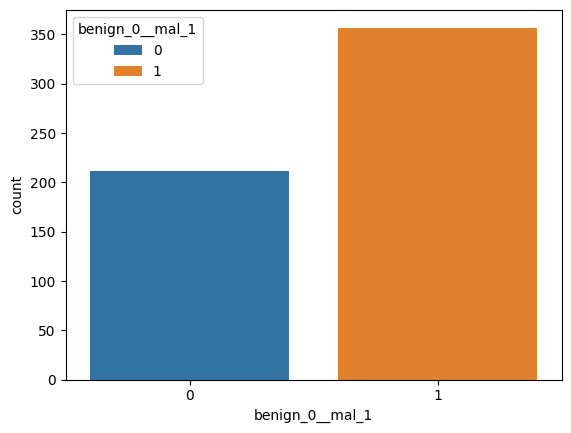

In [25]:
sns.countplot(x='benign_0__mal_1', data=df, hue='benign_0__mal_1')

<Axes: >

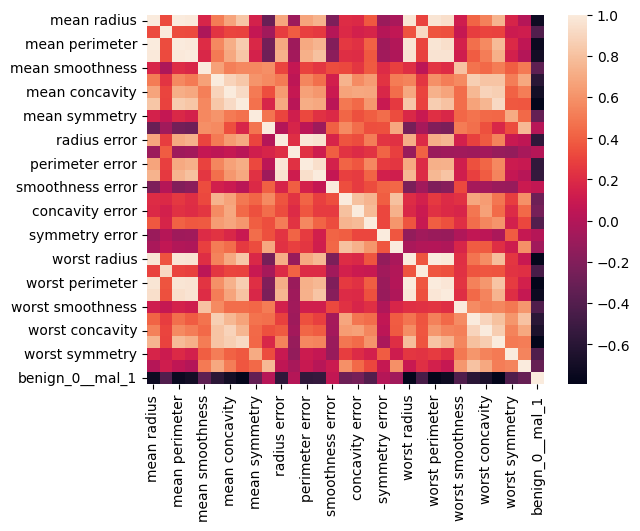

In [26]:
sns.heatmap(df.corr())

<Axes: >

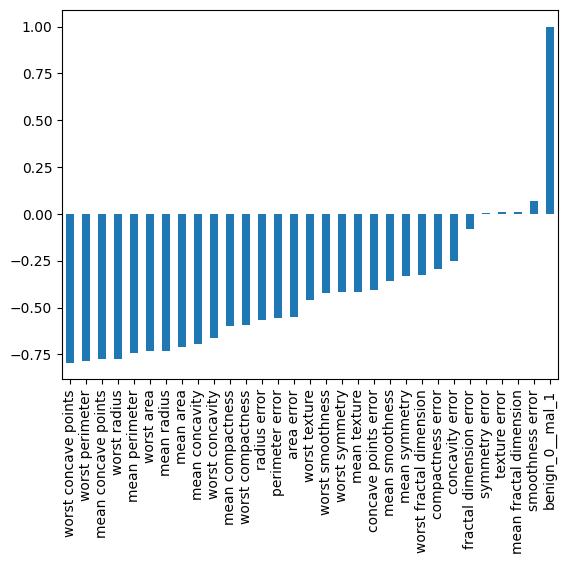

In [27]:
df.corr()['benign_0__mal_1'].sort_values().plot(kind='bar')

## Train Test Split

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X = df.drop('benign_0__mal_1', axis=1)
y = df['benign_0__mal_1']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


## Scaling Data

In [31]:
from sklearn.preprocessing import MinMaxScaler

In [32]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Creating the Model

    # For a binary classification problem
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
                  
    

In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

In [34]:
model = Sequential()
model.add(Dense(30, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

## Training the Model 

### Example One: Choosing too many epochs and overfitting!

In [35]:
model.fit(x=X_train, y=y_train, epochs=600, validation_data=(X_test, y_test))

Epoch 1/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6725 - loss: 0.6637 - val_accuracy: 0.8333 - val_loss: 0.6247
Epoch 2/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8308 - loss: 0.6076 - val_accuracy: 0.8421 - val_loss: 0.5780
Epoch 3/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8571 - loss: 0.5605 - val_accuracy: 0.8509 - val_loss: 0.5270
Epoch 4/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8769 - loss: 0.5125 - val_accuracy: 0.8947 - val_loss: 0.4782
Epoch 5/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8945 - loss: 0.4722 - val_accuracy: 0.8509 - val_loss: 0.4386
Epoch 6/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8945 - loss: 0.4290 - val_accuracy: 0.8684 - val_loss: 0.3986
Epoch 7/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8945 - loss: 0.3895 - val_accuracy: 0.8684 - val_loss: 0.3649
Epoch 8/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8989 - loss: 0.3522 - val_accuracy: 0.8684 - 

In [38]:
model.history.history

{'accuracy': [0.6725274920463562,
  0.8307692408561707,
  0.8571428656578064,
  0.8769230842590332,
  0.894505500793457,
  0.894505500793457,
  0.894505500793457,
  0.898901104927063,
  0.9054945111274719,
  0.9142857193946838,
  0.9120879173278809,
  0.9164835214614868,
  0.9142857193946838,
  0.9252747297286987,
  0.9230769276618958,
  0.9296703338623047,
  0.9252747297286987,
  0.9252747297286987,
  0.9384615421295166,
  0.9296703338623047,
  0.9384615421295166,
  0.9494505524635315,
  0.9406593441963196,
  0.9428571462631226,
  0.9384615421295166,
  0.9428571462631226,
  0.9560439586639404,
  0.9516483545303345,
  0.9538461565971375,
  0.9626373648643494,
  0.9604395627975464,
  0.9648351669311523,
  0.9670329689979553,
  0.9582417607307434,
  0.9648351669311523,
  0.9626373648643494,
  0.9714285731315613,
  0.9714285731315613,
  0.9692307710647583,
  0.9692307710647583,
  0.9780219793319702,
  0.9714285731315613,
  0.9736263751983643,
  0.9714285731315613,
  0.9692307710647583,
  

In [39]:
model_loss = pd.DataFrame(model.history.history)

<Axes: >

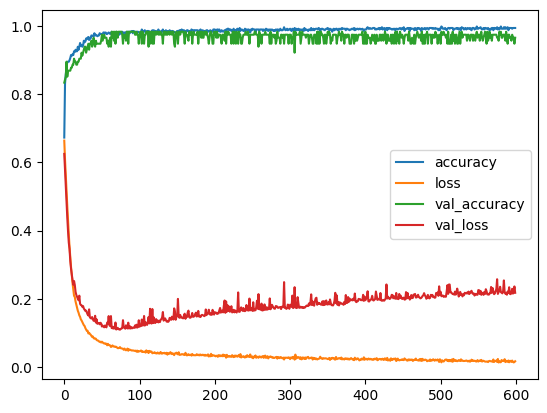

In [40]:
model_loss.plot()

## Example Two: Early Stopping

We obviously trained too much! Let's use early stopping to track the val_loss and stop training once it begins increasing too much!

In [41]:
from tensorflow.keras.callbacks import EarlyStopping

Stop training when a monitored quantity has stopped improving.

    Arguments:
        monitor: Quantity to be monitored.
        min_delta: Minimum change in the monitored quantity
            to qualify as an improvement, i.e. an absolute
            change of less than min_delta, will count as no
            improvement.
        patience: Number of epochs with no improvement
            after which training will be stopped.
        verbose: verbosity mode.
        mode: One of `{"auto", "min", "max"}`. In `min` mode,
            training will stop when the quantity
            monitored has stopped decreasing; in `max`
            mode it will stop when the quantity
            monitored has stopped increasing; in `auto`
            mode, the direction is automatically inferred
            from the name of the monitored quantity.

In [42]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

model.fit(x=X_train, y=y_train, epochs=600, validation_data=(X_test, y_test), callbacks=[early_stop])

Epoch 1/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9956 - loss: 0.0174 - val_accuracy: 0.9737 - val_loss: 0.2265
Epoch 2/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9956 - loss: 0.0144 - val_accuracy: 0.9474 - val_loss: 0.2259
Epoch 3/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9934 - loss: 0.0132 - val_accuracy: 0.9737 - val_loss: 0.2352
Epoch 4/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9934 - loss: 0.0204 - val_accuracy: 0.9474 - val_loss: 0.2374
Epoch 5/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9956 - loss: 0.0133 - val_accuracy: 0.9737 - val_loss: 0.2312
Epoch 6/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9978 - loss: 0.0161 - val_accuracy: 0.9737 - val_loss: 0.2235
Epoch 7/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9934 - loss: 0.0161 - val_accuracy: 0.9649 - val_loss: 0.2312
Epoch 8/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9912 - loss: 0.0153 - val_accuracy: 0.9561 - v

<Axes: >

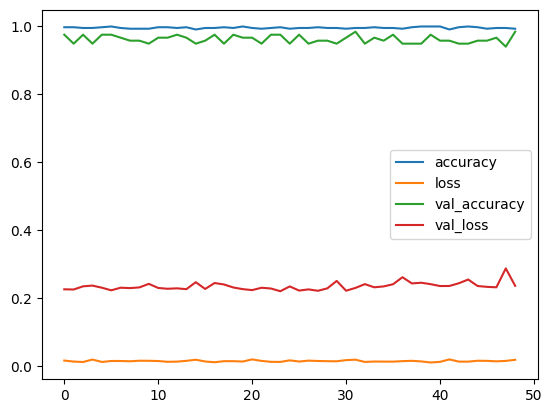

In [43]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

## Example Three: Adding in DropOut Layers

In [46]:
from tensorflow.keras.layers import Dropout

In [47]:
model = Sequential()

model.add(Dense(30, activation='relu'))
model.add(Dropout(0.5)) 

model.add(Dense(15, activation='relu'))
model.add(Dropout(0.5)) 

model.add(Dense(1, activation='sigmoid')) 

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(x=X_train, 
          y=y_train, 
          epochs=600, 
          validation_data=(X_test, y_test), 
          callbacks=[early_stop])

Epoch 1/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5319 - loss: 0.6938 - val_accuracy: 0.7982 - val_loss: 0.6617
Epoch 2/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5912 - loss: 0.6795 - val_accuracy: 0.8421 - val_loss: 0.6367
Epoch 3/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6286 - loss: 0.6571 - val_accuracy: 0.8596 - val_loss: 0.6135
Epoch 4/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6484 - loss: 0.6433 - val_accuracy: 0.8772 - val_loss: 0.5917
Epoch 5/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7231 - loss: 0.6190 - val_accuracy: 0.8947 - val_loss: 0.5639
Epoch 6/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7385 - loss: 0.6020 - val_accuracy: 0.8947 - val_loss: 0.5429
Epoch 7/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7429 - loss: 0.5896 - val_accuracy: 0.8947 - val_loss: 0.5249
Epoch 8/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8132 - loss: 0.5424 - val_accuracy: 0.9035 - 

<Axes: >

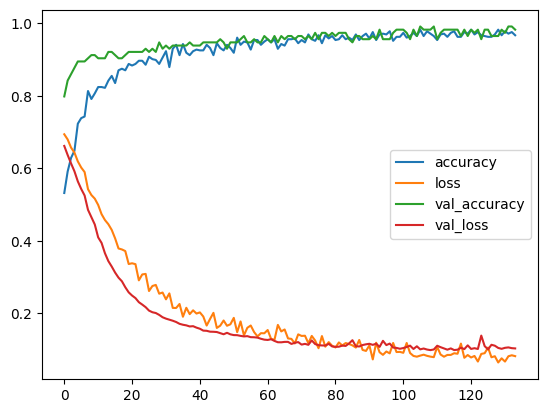

In [48]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

# Model Evaluation

In [49]:
from sklearn.metrics import classification_report,confusion_matrix

In [50]:
from sklearn.metrics import classification_report, confusion_matrix

predictions = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, predictions))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        48
           1       0.98      0.98      0.98        66

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [51]:
print(confusion_matrix(y_test, predictions))

[[47  1]
 [ 1 65]]


In [52]:
import joblib

joblib.dump(model, 'model_weights.pkl')

joblib.dump(scaler, 'scaler_weights.pkl')

['scaler_weights.pkl']